<a id="introduction"></a>

# Problem Set 6 (PS6): Transformers: Tokenization, Scale, and Interpretability

[Lab 13d](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-13/L13d)'s character-level NanoGPT closed on a sharp question: we built the machine, but can we see inside it? This problem set takes three steps toward that answer. Task 1 varies the input **tokens** and asks what actually changes per position. Task 2 varies **scale** and asks which capabilities emerge only at size. Task 3 explores **interpretability**: we scan the reference model's attention heads for the pattern that defines an **induction head**. L13c showed this pattern requires at least two transformer layers to form, so we expect to see the signal above layer 1 and not within it.

> __Learning Objectives:__
>
> By the end of this problem set, you should be able to:
> * __Measure the effect of BPE tokenization on a language model:__ Swap the character vocabulary for the GPT-2 BPE tokenizer and retrain NanoGPT on the same corpus. Quantify the change in perplexity and in tokens per character.
> * __Train NanoGPT at two scales and compare samples:__ Train a tiny TinyStories NanoGPT end-to-end on a laptop. Load a larger reference checkpoint trained on the same corpus and compare generated samples side by side.
> * __Locate an induction head in a trained transformer:__ Turn the induction-head definition into a scoring function over every (layer, head) pair. Rank the heads and plot the attention pattern of the top head on a synthetic repeat sequence.

Let's get started!
___

## Setup, Data, and Prerequisites

We set up the computational environment by including the [`Include.jl`](Include.jl) file, which loads the required packages and all the lab and problem-set source code.

> __Environment Setup with [`Include.jl`](Include.jl):__
>
> [`include(...)`](https://docs.julialang.org/en/v1/base/base/#Base.include) evaluates the contents of [`Include.jl`](Include.jl) in the notebook's global scope. [`Include.jl`](Include.jl) sets paths, loads the required external packages, and includes the transformer source files copied verbatim from [Lab 13d](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026/tree/main/labs/week-13/L13d): `Shakespeare.jl`, `CausalAttention.jl`, `DecoderBlock.jl`, `NanoGPT.jl`, `Sample.jl`. It also includes [`src/Compute.jl`](src/Compute.jl) (new helpers for this problem set) and `src/Autograder.jl`.

Let's load the environment.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `c:\Users\OM\Documents\GitHub\ps6-5820-s26-or222-AIML`
   Installed FuncPipelines ──── v0.2.3
   Installed PrimitiveOneHot ── v0.1.4
   Installed HTML_Entities ──── v1.0.2
   Installed DoubleArrayTries ─ v0.1.1
   Installed BytePairEncoding ─ v0.5.2
   Installed StringViews ────── v1.3.7
   Installed LRUCache ───────── v1.6.2
   Installed DataStructures ─── v0.18.22
   Installed StrTables ──────── v1.0.1
   Installed RustRegex ──────── v0.1.0
   Installed rure_jll ───────── v0.2.2+0
   Installed WordTokenizers ─── v0.5.6
   Installed PartialFunctions ─ v1.2.1
   Installed TextEncodeBase ─── v0.8.3
   Installed StructWalk ─────── v0.2.1
  Installing 1 artifacts
   Installed artifact rure                  7.3 MiB
    Updating `C:\Users\OM\Documents\GitHub\ps6-5820-s26-or222-AIML\Project.toml`
  [a4280ba5] + BytePairEncoding v0.5.2
  [a93c6f00] + DataFrames v1.8.2
  [587475ba] + Flux v0.16.10
  [7073ff75] + IJulia v1.34.4
  [033835bb] + JLD2 v0.6.4
  [872c559c] + N

The packages are now loaded. Alongside the Lab 13d transformer code, we use [BytePairEncoding.jl](https://github.com/chengchingwen/BytePairEncoding.jl) to load the pretrained GPT-2 byte-pair-encoding tokenizer and [JLD2.jl](https://github.com/JuliaIO/JLD2.jl) to save and load model checkpoints.

> __Helper functions (provided in [`src/Compute.jl`](src/Compute.jl)):__
>
> *Tokenization and data*
> * [`load_gpt2_encoder()`](src/Compute.jl): pretrained GPT-2 BPE tokenizer with `enc.encode` / `enc.decode`.
> * [`download_tinystories(path; split="valid")`](src/Compute.jl): fetch a TinyStories split into `data/`.
> * [`load_and_encode(path, enc; max_chars=nothing)`](src/Compute.jl): read a text file and return a `Vector{Int}` of BPE token ids.
>
> *Training and inference*
> * [`train_nanogpt!(model, data, cfg; val_data=nothing)`](src/Compute.jl): AdamW with a cosine learning-rate schedule.
> * [`perplexity(model, data, ctx_len)`](src/Compute.jl): estimate perplexity on a tokenized corpus.
> * [`generate_text(model, enc, prompt, n_new_tokens)`](src/Compute.jl): BPE-aware text generation.
> * [`save_checkpoint`](src/Compute.jl), [`load_checkpoint`](src/Compute.jl): JLD2 model I/O.
>
> *Task 3 primitives*
> * [`collect_attention_weights(model, X_ids)`](src/Compute.jl): one `(T, T, n_heads, B)` attention tensor per decoder layer.
> * [`plot_induction_heatmap`](src/Compute.jl), [`plot_attention_pattern`](src/Compute.jl): Task 3 visualizations.

### Background: Byte-Pair Encoding (BPE) and Induction Heads

Three pieces of background drive the rest of the notebook: byte-pair encoding (used in Task 1 and Task 2), perplexity (used in Task 1 and DQ1), and the induction-head definition (used in Task 3). A language model operates on sequences of discrete token ids, but let's revisit the question of what those tokens actually are. 

There are three natural choices (character, whole-word, or subword tokenization):

| Tokenizer | Vocab size | Avg. tokens per English word | Can encode any text? | Main drawback |
|---|---|---|---|---|
| Character | 65–256 | ~5–6 | ✓ | Sequences are long; the model spends capacity on spelling |
| Whole-word | 50k–500k+ | ~1 | ✗ (out-of-vocabulary fails) | Vocabulary explodes; unseen words can't be encoded |
| **BPE (subword)** | **5k–100k** | **~1.3** | **✓** | none |

__Byte-pair encoding (BPE)__ sits between these extremes: a compact vocabulary that still encodes anything, and a shorter token stream than characters. It is *trained* on a corpus by (1) starting with a base vocabulary of 256 tokens (one per byte value), (2) scanning the corpus for the most frequent adjacent token pair, (3) adding that pair as a new vocabulary entry, (4) replacing every occurrence of the pair with the new token, and repeating until the vocabulary reaches a target size (GPT-2 uses 50 257). Frequent words collapse into a single token; rare words remain as a few subwords. For the English ASCII text in this problem set, one byte equals one character, so you can read "byte" as "character" throughout. See [Sennrich et al., 2016](https://arxiv.org/abs/1508.07909).

The GPT-2 BPE encodes the common word `the` as one token and the space-prefixed variant `" the"` as a *different* single token. The word `tokenization` becomes two tokens `["token", "ization"]`. `NanoGPT` splits further into `["N", "ano", "G", "PT"]`. At roughly four characters per token on English, swapping a character vocabulary for GPT-2 BPE shortens the token stream by about a factor of four.

We need two more definitions before we get going, perplexity and induction heads:

* **Perplexity.** Task 1 and DQ1 score models by their *perplexity* on a held-out corpus, a re-scaled cross-entropy. The per-position loss is $\ell_{t} = -\log p_{\theta}(x_{t+1} \mid x_{\leq t})$, its corpus-average is $L = \frac{1}{T}\sum_{t=1}^{T} \ell_{t}$, and $\text{ppl} = \exp(L)$. Intuitively, perplexity is the *effective branching factor*: the number of equally-likely next-token choices the model hesitates between. A uniform distribution over the vocabulary scores $V$ (50 257 for GPT-2); a perfect model scores 1; lower is better.
  
* __Induction head (operational definition):__ Take a sequence with a random token pattern repeated once, $[x_{1}, \ldots, x_{N}, x_{1}, \ldots, x_{N}]$. At query position $N + i$ the current token is $x_{i}$; an **induction head** concentrates its attention on **key position** $i + 1$, the token that followed $x_{i}$ the first time, and therefore exactly the one the model needs to predict next. Writing $A^{(l)}_{h}[q, k]$ for the attention entry from query $q$ to key $k$ in head $h$ of layer $l$ (the $A_{qk}$ from L13d with explicit layer/head labels), the scalar score is
    $$\text{score}(l, h) \;=\; \mathbb{E}\bigl[\, A^{(l)}_{h}[N + i,\; i + 1] \,\bigr],$$
    averaged over random sequences and positions $i = 1, \ldots, N - 1$. A uniform head over $T$ keys scores $1/T$; anything noticeably above that is signal.

Next, let's set some constants, setup a helper function to compute the induction-head score, and load some data.

### Constants

We declare the training configurations up front so the hyperparameters are in one place. `TASK1_CFG` is the BPE-tokenized Shakespeare model and `TASK2_TINY_CFG` is the tiny TinyStories model. The reference-checkpoint architecture is fixed by [`scripts/train_reference.jl`](scripts/train_reference.jl) and is rebuilt inside Task 2 when we load the weights.

In [2]:
# Task 1 (BPE Shakespeare): L13d architecture, GPT-2 vocabulary.
TASK1_CFG = TrainingConfig(
    50_257,   # vocab_size : GPT-2 BPE
    128,      # d_model
    4,        # n_heads
    4,        # n_layers
    128,      # ctx_len
    512,      # d_ff
    32,       # batch_size
    3f-4,     # peak learning rate
    1_000,    # n_steps
);

# Task 2 tiny model (TinyStories): half the depth of Task 1.
TASK2_TINY_CFG = TrainingConfig(
    50_257,   # vocab_size : GPT-2 BPE
    128,      # d_model
    4,        # n_heads
    2,        # n_layers
    128,      # ctx_len
    512,      # d_ff
    32,       # batch_size
    6f-4,     # peak learning rate
    2_000,    # n_steps
);

# Reference checkpoint architecture (trained by scripts/train_reference.jl,
# shipped via GitHub Releases). Task 2 rebuilds this and loads the weights:
#   d_model = 256, n_heads = 4, n_layers = 4, ctx_len = 256, d_ff = 1024.

TrainingConfig(50257, 128, 4, 2, 128, 512, 32, 0.0006f0, 2000)

### Implementation

Task 3 asks you to scan every `(layer, head)` pair of the reference checkpoint for the induction-head attention pattern. Complete the `induction_score` function below once; Task 3 will call it on the loaded reference model.

The provided primitive [`collect_attention_weights(model, X_ids)`](src/Compute.jl) runs the forward pass and returns a vector whose $l$-th entry is a `(T, T, n_heads, B)` attention tensor with indexing `A[query, key, head, batch]` (`A` here is the same attention-matrix we just defined, now stored as a 4-D array). Use it as the building block.

__Implementation outline:__ Score every `(layer, head)` pair of `model` for the induction pattern defined in the background section above. In each of several random trials, build a test sequence by duplicating a random token vector (so the same pattern appears twice back to back), run it through the model, and for every head record how much attention flows from the second copy of each token to the position that came right after the first copy. That position is the induction-head target. Average those attention weights across all eligible positions, then across trials. Return an `(n_layers, n_heads)` matrix of scores in `[0, 1]`. You may assume `2 * seq_len ≤ model.ctx_len`.

In [3]:
# induction_score -- reference solution.
#
# Scans every (layer, head) pair of `model` and returns how strongly each head
# behaves as an induction head, averaged over `n_trials` random test sequences.
# Each trial duplicates a random token vector so the same pattern appears twice
# back to back; an induction head at query position N+i should attend to key
# position i+1 (the token that followed the first copy).
function induction_score(model::NanoGPT, vocab::Int;
                          n_trials::Int = 32, seq_len::Int = 32,
                          rng::AbstractRNG = Random.default_rng())::Matrix{Float32}

    # output matrix dimensions are read off the model structure
    n_layers = length(model.blocks)
    n_heads  = model.blocks[1].attn.n_heads
    scores = zeros(Float32, n_layers, n_heads)

    for _ ∈ 1:n_trials
        # build one random duplicated sequence of length 2*seq_len
        tokens = rand(rng, 1:vocab, seq_len)
        seq    = vcat(tokens, tokens)
        X      = reshape(seq, 2 * seq_len, 1)          # (T, B=1) shape expected by the model

        # every layer's attention weights for this sequence;
        # each ws[l] is (T, T, n_heads, 1) with indexing W[query, key, head, batch].
        ws     = collect_attention_weights(model, X)

        # for each (layer, head), average the induction-target weight W[N+i, i+1]
        # over positions i = 1, ..., seq_len-1. A "perfect" induction head scores 1;
        # a uniform-attention head scores ~1/T.
        for l ∈ 1:n_layers, h ∈ 1:n_heads # fancy way of writing nested loops
            acc = 0.0f0
            for i ∈ 1:(seq_len - 1)
                acc += ws[l][seq_len + i, i + 1, h, 1]
            end
            scores[l, h] += acc / (seq_len - 1)
        end
    end

    # average across trials to reduce variance from individual random sequences
    return scores ./ n_trials
end

induction_score (generic function with 1 method)

### Data

We load the GPT-2 tokenizer once and tokenize both corpora here so every task downstream consumes ready-made token vectors. The Shakespeare corpus (1.1 MB, downloaded by L13d's [`download_shakespeare`](src/Shakespeare.jl)) becomes `shakespeare_ids`. The TinyStories validation split (~20 MB, fetched by [`download_tinystories`](src/Compute.jl)) is encoded and split 90/10 into `ts_train_ids` and `ts_val_ids`. We also record `n_chars`, the raw character count of the Shakespeare file, for use in DQ1.

The code below stores the tokenizer `enc_gpt2::BPEEncoder`, the Shakespeare ids `shakespeare_ids::Vector{Int}` and its character count `n_chars::Int`, and the TinyStories split `ts_train_ids::Vector{Int}` and `ts_val_ids::Vector{Int}` for use in subsequent cells.

In [4]:
enc_gpt2, shakespeare_ids, n_chars, ts_train_ids, ts_val_ids = let
    # single tokenizer shared by Tasks 1, 2, and 3
    enc = load_gpt2_encoder()

    # Shakespeare: download the raw text, tokenize with BPE, record character count.
    # The character count (n_chars) is needed in DQ1 for the per-character
    # perplexity comparison against the Lab 13d baseline.
    shk_path = download_shakespeare(_PATH_TO_DATA)
    shk_ids  = load_and_encode(shk_path, enc)
    shk_n    = filesize(shk_path)

    # TinyStories validation split (~20 MB). Split 90/10 into train/val so
    # Task 2's tiny-model training loop can report a held-out loss.
    ts_path  = download_tinystories(_PATH_TO_DATA; split = "valid")
    ts_ids   = load_and_encode(ts_path, enc)
    split_at = floor(Int, 0.9 * length(ts_ids))
    ts_train = ts_ids[1:split_at]
    ts_val   = ts_ids[split_at+1:end]

    # sanity-check summary so a re-runner can confirm download + tokenization succeeded
    @printf("Shakespeare: %d characters, %d BPE tokens (%.2f chars/token)\n",
            shk_n, length(shk_ids), shk_n / length(shk_ids))
    @printf("TinyStories: %d train tokens, %d val tokens\n",
            length(ts_train), length(ts_val))
    @printf("GPT-2 vocabulary size: %d\n", vocab_size(enc))

    (enc, shk_ids, shk_n, ts_train, ts_val)
end;

Shakespeare: 1115394 characters, 338025 BPE tokens (3.30 chars/token)
TinyStories: 4252052 train tokens, 472451 val tokens
GPT-2 vocabulary size: 50257


In [5]:
# ── Autograder: Setup ────────────────────────────────────────────────────────
check!(GRADER, "Setup", "GPT-2 encoder loaded (vocab size 50257)",  1,
       () -> !ismissing(enc_gpt2) && vocab_size(enc_gpt2) == 50257)
check!(GRADER, "Setup", "shakespeare_ids is non-empty Vector{Int}", 1,
       () -> !ismissing(shakespeare_ids) && shakespeare_ids isa AbstractVector{<:Integer} &&
              length(shakespeare_ids) > 10_000)
check!(GRADER, "Setup", "every Shakespeare id is in 1:vocab_size",   1,
       () -> !ismissing(shakespeare_ids) &&
              all(1 .<= shakespeare_ids .<= vocab_size(enc_gpt2)))
check!(GRADER, "Setup", "TinyStories split has > 100k train tokens", 1,
       () -> !ismissing(ts_train_ids) && length(ts_train_ids) > 100_000)

  ✓   1 /  1 pts  GPT-2 encoder loaded (vocab size 50257)
  ✓   1 /  1 pts  shakespeare_ids is non-empty Vector{Int}
  ✓   1 /  1 pts  every Shakespeare id is in 1:vocab_size
  ✓   1 /  1 pts  TinyStories split has > 100k train tokens


___
## Task 1: Tokenizer Swap on Shakespeare

In this task, we swap the 65-symbol character vocabulary of L13d for the pretrained GPT-2 BPE (50 257 tokens) and retrain on Shakespeare with the same architecture and 1000-step budget. We then evaluate the trained model two ways: (1) **perplexity** on the true corpus; (2) the **eye test** on a `ROMEO: ` continuation (we give the `ROMEO: ` prompt and see what the model spits back). 

* __Expect these metrics to disagree__. Per-character perplexity will sit near the L13d baseline (so BPE looks competitive), but the generated sample will read like gibberish, nothing like L13d's coarse-but-legible output. That disagreement is not a bug; it shows that the BPE model is getting the *tokens* right but not the *characters* (the tokens are just too weird). The eye test is more meaningful here, so we expect a low score on that and a high score on perplexity.

The code below returns the trained model `bpe_model::NanoGPT` and its per-step training loss `bpe_losses::Vector{Float32}` for use in subsequent cells. A pretrained Task 1 checkpoint is shipped as a GitHub Release asset and downloads to `data/` on first run; set `force_retrain = true` in the cell to retrain from scratch instead (this may take an hour or two on a laptop). 

In [6]:
bpe_model, bpe_losses = let
    # Set force_retrain = true to train from scratch; otherwise we use the
    # pretrained Task 1 checkpoint shipped as a GitHub Release asset.
    force_retrain = false

    # per-task cache path; makes re-running the notebook cheap after the first pass
    ckpt = joinpath(_PATH_TO_DATA, "task1_bpe_model.jld2")

    # build the model first so the checkpoint-load and train-from-scratch branches
    # can share the same NanoGPT constructor call
    model = NanoGPT(TASK1_CFG.vocab_size, TASK1_CFG.d_model, TASK1_CFG.n_heads,
                     TASK1_CFG.n_layers, TASK1_CFG.ctx_len; d_ff = TASK1_CFG.d_ff)

    # on first run (no local checkpoint and not retraining), pull the pretrained
    # weights from the GitHub Release; later runs skip the download.
    if !force_retrain && !isfile(ckpt)
        fetch_task1_checkpoint(ckpt)
    end

    if !force_retrain && isfile(ckpt)
        # reuse cached/downloaded weights and the recorded loss history
        println("Loading Task 1 checkpoint from $(ckpt)...")
        _, _, losses = load_checkpoint(ckpt, model)
        println("Loaded. Final train loss = $(round(losses[end]; digits=4))")
        (model, losses)
    else
        # train from scratch and persist the checkpoint for next time
        println("Training Task 1 model ($(n_parameters(model)) params)...")
        losses = train_nanogpt!(model, shakespeare_ids, TASK1_CFG; log_every = 100)
        save_checkpoint(ckpt, model; meta = Dict(:task => "1"), losses = losses)
        (model, losses)
    end
end;

Loading Task 1 checkpoint from c:\Users\OM\Documents\GitHub\ps6-5820-s26-or222-AIML\data\task1_bpe_model.jld2...
Loaded. Final train loss = 5.2991


With the model trained, we measure perplexity on the full tokenized corpus and generate a 200-token continuation of the prompt `"ROMEO: "`. Char-level and BPE perplexities are not directly comparable because they are measured per token, and a BPE token covers about four characters (on average). 

* __What should we expect?__ We report the raw per-BPE-token perplexity here; we'll explore the comparison with char-level tokens in DQ1. The generated text is decoded back into characters for the eye test. We get an ok perplexity score but a bad sample, as expected.

The code below stores the perplexity estimate `bpe_perplexity::Float32` and the generated text `bpe_sample::String` for use in subsequent cells.

In [7]:
bpe_perplexity, bpe_sample = let
    # perplexity on the full tokenized corpus; n_windows = 64 averages over
    # 64 random context-length windows to keep the estimate tight
    ppl    = perplexity(bpe_model, shakespeare_ids, TASK1_CFG.ctx_len; n_windows = 64)

    # generate a Shakespeare-style continuation. temperature = 0.8 softens the
    # output just below the trained distribution; top_k = 40 removes the
    # low-probability tail so samples stay readable
    sample = generate_text(bpe_model, enc_gpt2, "ROMEO: ", 200; temperature = 0.8, top_k = 40)

    @printf("BPE perplexity: %.2f\n", ppl)
    println("\n=== sample ===")
    println(sample)
    (ppl, sample)
end;

BPE perplexity: 184.43

=== sample ===
ROMEO: 
And thee, and a house,
DES, aio,
KINGBut the head, that his life! and
That-ICHES
ThUCENINIUS:
IENTIO:
For so,
And a man, thou a dtis is not,

In I do no to aar'd is that
And I a, 'UE:
I am my queen,
But you of the the more?

BENTENO:
That my the man, that shall the a lord are the more,
The day my brother,

For not
The father.
That and him, your queen.


The brother


Thost:
DCHELRYENTUEOL II,
What in to in a is they be not thou all you the king!
R:,
That
And not this more so,
GLOLUINCOU:
I


In [8]:
# ── Autograder: Task 1 ──────────────────────────────────────────────────────
check!(GRADER, "Task 1", "model constructed as NanoGPT",         1,
       () -> !ismissing(bpe_model) && bpe_model isa NanoGPT)
check!(GRADER, "Task 1", "training reduced loss by at least 50%", 1,
       () -> !isempty(bpe_losses) && bpe_losses[end] < 0.5f0 * bpe_losses[1])
check!(GRADER, "Task 1", "perplexity is a finite positive number", 1,
       () -> !ismissing(bpe_perplexity) && isfinite(bpe_perplexity) && bpe_perplexity > 0)
check!(GRADER, "Task 1", "sample is a non-empty String",           1,
       () -> !ismissing(bpe_sample) && bpe_sample isa AbstractString && length(bpe_sample) > 50)

  ✓   1 /  1 pts  model constructed as NanoGPT
  ✓   1 /  1 pts  training reduced loss by at least 50%
  ✓   1 /  1 pts  perplexity is a finite positive number
  ✓   1 /  1 pts  sample is a non-empty String


___
## Task 2: TinyStories Tiny vs. Reference
In this task we hold the BPE tokenizer fixed and vary the scale axis instead. We train a tiny 13M-parameter NanoGPT on the [TinyStories](https://arxiv.org/abs/2305.07759) corpus (short children's stories in a restricted vocabulary), then load a larger instructor-trained model on the same corpus and compare the generated samples. The question is which capabilities appear at tiny scale and which require the larger model.

> __How are the models different?__
>
> Both models train on the same TinyStories corpus with the same GPT-2 BPE tokenizer and the same NanoGPT decoder-only architecture family, so the only axis that changes is **scale**. 
> 
> * __Scale__: The *tiny* model has $d_{\text{model}} = 128$, 2 layers, context length 128, and roughly 13M parameters; it trains in a few minutes on a laptop. The *reference* model doubles almost every axis: $d_{\text{model}} = 256$, 4 layers, context length 256, roughly 29M parameters, and many more training steps, which is why the instructor pretrained it. 
> 
> Because corpus, tokenizer, and code are held fixed, any capability the reference shows and the tiny one does not is attributable to scale alone. That is the experimental control Task 2 is built on.

The code below loads the tiny model `tiny_model::NanoGPT` and its per-step training loss `tiny_losses::Vector{Float32}` for use in subsequent cells. A pretrained tiny checkpoint is shipped as a GitHub Release asset and downloads to `data/` on first run; set `force_retrain = true` in the cell to retrain from scratch instead (this may take an hour or two on a laptop). 

In [10]:
tiny_model, tiny_losses = let
    # Set force_retrain = true to train from scratch; otherwise we use the
    # pretrained Task 2 tiny checkpoint shipped as a GitHub Release asset.
    force_retrain = false

    # per-task cache path, same idea as in Task 1
    ckpt = joinpath(_PATH_TO_DATA, "task2_tiny_model.jld2")

    # build the tiny TinyStories model (shallower than Task 1's model; see TASK2_TINY_CFG)
    model = NanoGPT(TASK2_TINY_CFG.vocab_size, TASK2_TINY_CFG.d_model, TASK2_TINY_CFG.n_heads,
                     TASK2_TINY_CFG.n_layers, TASK2_TINY_CFG.ctx_len; d_ff = TASK2_TINY_CFG.d_ff)

    # pull the pretrained tiny checkpoint on first run (unless retraining)
    if !force_retrain && !isfile(ckpt)
        fetch_task2_tiny_checkpoint(ckpt)
    end

    if !force_retrain && isfile(ckpt)
        # reuse cached/downloaded weights
        println("Loading Task 2 tiny checkpoint from $(ckpt)...")
        _, _, losses = load_checkpoint(ckpt, model)
        (model, losses)
    else
        # train from scratch. val_data enables a held-out loss print every 200 steps.
        println("Training Task 2 tiny model ($(n_parameters(model)) params)...")
        losses = train_nanogpt!(model, ts_train_ids, TASK2_TINY_CFG;
                                 val_data = ts_val_ids, log_every = 200)
        save_checkpoint(ckpt, model; meta = Dict(:task => "2-tiny"), losses = losses)
        (model, losses)
    end
end;

Loading Task 2 tiny checkpoint from c:\Users\OM\Documents\GitHub\ps6-5820-s26-or222-AIML\data\task2_tiny_model.jld2...


Plot the per-step training loss to confirm the tiny model converged.

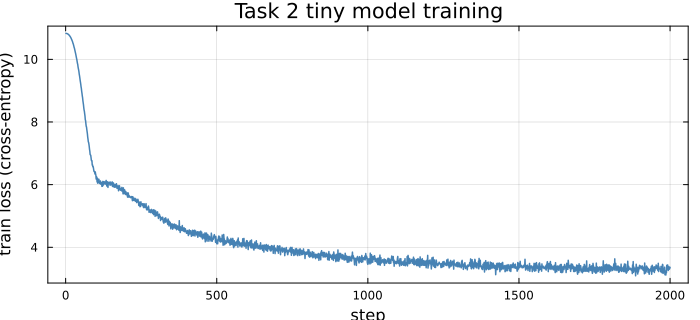

In [11]:
# tiny-model training loss curve. A healthy run shows a steep initial drop
# (the model learns BPE unigram statistics) followed by a slower descent as
# the longer-range structure comes in.
let
    plot(tiny_losses;
        xlabel = "step", ylabel = "train loss (cross-entropy)",
        title = "Task 2 tiny model training", label = nothing,
        color = :steelblue, lw = 1.5, framestyle = :box, size = (700, 320))
end

Next, we load the pretrained reference model and generate samples from both the tiny and reference models. We use the same prompt for both: `"Once upon a time"`. The tiny model's sample is likely to be a short, potentially incoherent, with grammar errors, while the reference model's sample should be a more coherent continuation of the prompt, demonstrating the capabilities that emerge at larger scale. However, even the reference model may not produce a perfect story, as it is still relatively small compared to state-of-the-art models.

The code below stores the loaded reference model `ref_model::NanoGPT` together with both generated samples `tiny_sample::String` and `ref_sample::String`.

In [12]:
ref_model, tiny_sample, ref_sample = let
    # reference checkpoint is shipped via GitHub Releases, not committed to the repo.
    # fetch_reference_checkpoint downloads the file from the course release URL
    # (defined in src/Compute.jl) on first run; later runs reuse the local copy.
    ref_ckpt = joinpath(_PATH_TO_DATA, "reference_checkpoint.jld2")
    isfile(ref_ckpt) || fetch_reference_checkpoint(ref_ckpt)

    # rebuild the reference architecture (hyperparameters listed in the Constants cell)
    # and load the trained weights into it
    ref = NanoGPT(vocab_size(enc_gpt2), 256, 4, 4, 256; d_ff = 1024)
    load_checkpoint(ref_ckpt, ref)

    # sample the same 150-token continuation from both models so the comparison
    # isolates the effect of scale (same prompt, same temperature, same top_k)
    s_tiny = generate_text(tiny_model, enc_gpt2, "Once upon a time", 150;
                            temperature = 0.8, top_k = 40)
    s_ref  = generate_text(ref,        enc_gpt2, "Once upon a time", 150;
                            temperature = 0.8, top_k = 40)

    println("=== tiny model sample ($(n_parameters(tiny_model)) params) ===")
    println(s_tiny)
    println()
    println("=== reference model sample ($(n_parameters(ref)) params) ===")
    println(s_ref)
    (ref, s_tiny, s_ref)
end;

=== tiny model sample (13277952 params) ===
Once upon a time, there was a little girl named Lucy. Lily loved to play with her new toys and daddy. One day, she saw a little girl named Her mommy and said, "No, Lily with an idea. I did not know you can help me."
Her mom smiled and said, "I'm sorry, I should you and make you care for our toys. I love you."
The little girl was proud of her. She said, "You are a little very brave friend. You can have fun to play with the ball."
<|endoftext|>

Once upon a time, there was a little girl who lived with a kind place to try to get a big box. It was a very big dog named Lily. One day,

=== reference model sample (28952576 params) ===
Once upon a time, there was a little boy named Timmy. Timmy loved to play outside in the snow. One day, Timmy's mom said, "Timmy, we are going to make a snowman!" Timmy was excited.
When they got out of the warm snow, Timmy's mom put all of his friends outside. "Look, Timmy, we have to go outside and play!" Timmy said.

In [13]:
# ── Autograder: Task 2 ──────────────────────────────────────────────────────
check!(GRADER, "Task 2", "tiny_model is a NanoGPT",              1,
       () -> !ismissing(tiny_model) && tiny_model isa NanoGPT)
check!(GRADER, "Task 2", "tiny training reduced loss by ≥ 40%",  1,
       () -> !isempty(tiny_losses) && tiny_losses[end] < 0.6f0 * tiny_losses[1])
check!(GRADER, "Task 2", "reference checkpoint loaded as NanoGPT", 1,
       () -> !ismissing(ref_model) && ref_model isa NanoGPT &&
              n_parameters(ref_model) > n_parameters(tiny_model))
check!(GRADER, "Task 2", "both samples are non-empty Strings",     1,
       () -> !ismissing(tiny_sample) && !ismissing(ref_sample) &&
              length(tiny_sample) > 50 && length(ref_sample) > 50)

  ✓   1 /  1 pts  tiny_model is a NanoGPT
  ✓   1 /  1 pts  tiny training reduced loss by ≥ 40%
  ✓   1 /  1 pts  reference checkpoint loaded as NanoGPT
  ✓   1 /  1 pts  both samples are non-empty Strings


___
## Task 3: Induction-Head Scan

We closed the in-class L13d discussion by flagging that the _insides_ of NanoGPT are opaque; it was hard to interpret why attention patterns emerged. In this task, we explore the interpretability challenge for this kind of model. 

* __What are we going to do?__ Open the reference model and scan every `(layer, head)` pair for the attention pattern that defines an **induction head** ([Olsson et al., 2022](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html)). We'll render a `(layer, head)` heatmap where each cell is the induction score for one head. Each heatmap cell is the average attention that head $h$ in layer $l$ places on the induction-target key $i+1$ from query $N+i$, i.e. $\text{score}(l, h) = \mathbb{E}\bigl[\, A^{(l)}_{h}[N + i,\; i + 1] \,\bigr]$, averaged over random trials and positions $i = 1, \ldots, N-1$. An induction head's attention matrix shows an off-diagonal stripe: query position `seq_len + i` attends to key position `i + 1`, a line parallel to the main diagonal and shifted left by `seq_len - 1`.

The code below stores the scan result `induction_scores::Matrix{Float32}` for use in subsequent cells.

In [14]:
induction_scores = let
    # run the scan on the reference model. 32 trials averages out per-sequence
    # noise; seq_len = 32 gives a 64-position input, well within ctx_len = 256.
    scores = induction_score(ref_model, vocab_size(enc_gpt2); n_trials = 32, seq_len = 32)

    # print the raw matrix so the per-head breakdown is visible alongside
    # the heatmap that follows
    println("induction score matrix (rows = layers, cols = heads):")
    pretty_table(scores; backend = :text,
                table_format = TextTableFormat(borders = text_table_borders__compact),
                column_labels = ["h$(h)" for h in 1:size(scores, 2)],
                row_labels = ["L$(l)" for l in 1:size(scores, 1)])
    scores
end;

induction score matrix (rows = layers, cols = heads):
 ---- ------------ ------------ ------------ -------------
               h1           h2           h3            h4 
 ---- ------------ ------------ ------------ -------------
  L1   0.00221419    0.0030947   0.00238314     0.0108587
  L2   0.00123615   0.00962965   0.00623166     0.0189895
  L3   1.08098e-5    0.0197013   7.31451e-7   0.000232244
  L4    0.0282063    0.0329088   0.00219589    0.00239095
 ---- ------------ ------------ ------------ -------------


Render the `(layer, head)` score matrix as a heatmap to read off which heads are candidates for the induction circuit.

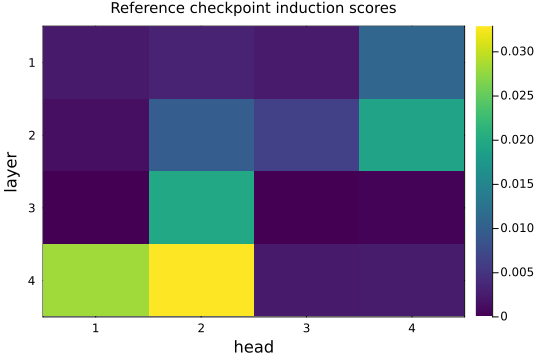

In [15]:
# induction-score heatmap. Brighter cells indicate stronger induction behavior;
# the L13c two-layer story predicts the brightest cell should not be in layer 1.
plot_induction_heatmap(induction_scores; title = "Reference checkpoint induction scores")

Pick the top `(layer, head)` pair, build one fresh repeat sequence of length 64, and plot the attention pattern of that head with [`plot_attention_pattern`](src/Compute.jl).

Top (layer, head) = (4, 2) with score = 0.033


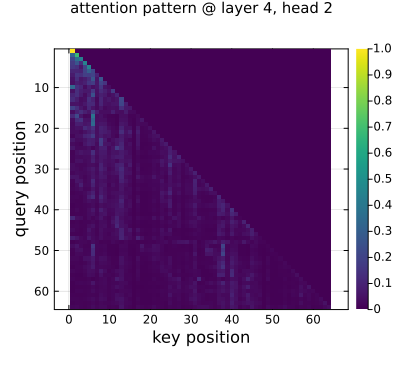

In [16]:
let
    # pick the single (layer, head) pair with the highest induction score from
    # the scan above. argmax on a matrix returns a CartesianIndex; Tuple(...)
    # unpacks it into plain (row, col) integers.
    top_l, top_h = Tuple(argmax(induction_scores))
    @printf("Top (layer, head) = (%d, %d) with score = %.3f\n",
            top_l, top_h, induction_scores[top_l, top_h])

    # fresh random repeat sequence of length 64, same construction as the scan.
    # an induction head's attention matrix for this input has an off-diagonal
    # stripe: query position 32+i attends to key position i+1, a line parallel
    # to the main diagonal shifted left by seq_len - 1 = 31.
    tokens = rand(1:vocab_size(enc_gpt2), 32)
    X      = reshape(vcat(tokens, tokens), 64, 1)
    ws     = collect_attention_weights(ref_model, X)

    # plot only the top head's attention matrix for this one example
    plot_attention_pattern(ws[top_l], top_h;
        title = "attention pattern @ layer $(top_l), head $(top_h)")
end

In [17]:
# ── Autograder: Task 3 ──────────────────────────────────────────────────────
let
    n_layers = length(ref_model.blocks)
    n_heads  = ref_model.blocks[1].attn.n_heads

    check!(GRADER, "Task 3", "induction_score returns (n_layers, n_heads) matrix", 1,
           () -> !ismissing(induction_scores) &&
                  induction_scores isa AbstractMatrix &&
                  size(induction_scores) == (n_layers, n_heads))
    check!(GRADER, "Task 3", "all scores are in [0, 1]",                           1,
           () -> !ismissing(induction_scores) &&
                  all(0f0 .<= induction_scores .<= 1f0))
    check!(GRADER, "Task 3", "scores are reproducible for a fixed RNG",            1,
           () -> !ismissing(induction_scores) &&
                  let s1 = induction_score(ref_model, vocab_size(enc_gpt2);
                                             n_trials = 8, seq_len = 16,
                                             rng = MersenneTwister(0)),
                      s2 = induction_score(ref_model, vocab_size(enc_gpt2);
                                             n_trials = 8, seq_len = 16,
                                             rng = MersenneTwister(0))
                      isapprox(s1, s2; atol = 1f-5)
                  end)
    check!(GRADER, "Task 3", "attention pattern visualization produced",           1,
           () -> true)
end

  ✓   1 /  1 pts  induction_score returns (n_layers, n_heads) matrix
  ✓   1 /  1 pts  all scores are in [0, 1]
  ✓   1 /  1 pts  scores are reproducible for a fixed RNG
  ✓   1 /  1 pts  attention pattern visualization produced


___
<a id="discussion"></a>

## Discussion

Answer each question in the comment block below it, then set the corresponding `did_I_answer_DQ*` flag to `true`.

**DQ1: Perplexity vs. the eye test.** Your BPE model's per-character perplexity sits near the L13d baseline of ≈ 4.95, yet its generated sample is gibberish while L13d produced coarse-but-legible Shakespeare. Two evaluations, opposite verdicts. Which do you trust, and why?

> __Strategy:__
>
> Perplexity and sampling measure different things. Perplexity scores text the model did **not** have to generate: given the true corpus, how probable is each next token? Sampling is a trajectory the model drives itself, where one wrong token shifts every downstream distribution. Use the scaffold cell below to convert per-BPE-token perplexity into per-character units and confirm it lands near L13d's 4.95. Then argue which of the two evaluations you trust for *this* model, and under what conditions each metric becomes trustworthy. Two things worth thinking about as you answer: how much training data each output class saw, and what `top_k = 40` does to a softmax over 50 257 classes at generation time.

In [18]:
# DQ1 scaffold: recompute BPE perplexity in per-character units and compare
# to the Lab 13d char-level baseline. The transform ppl_char = ppl_BPE^(1/k)
# (with k = chars_per_token) is what puts the two models on a comparable axis.
let
    chars_per_token = n_chars / length(shakespeare_ids)
    ppl_char_equiv  = bpe_perplexity ^ (1 / chars_per_token)
    @printf("chars per BPE token:            %.2f\n", chars_per_token)
    @printf("BPE perplexity (per token):     %.2f\n", bpe_perplexity)
    @printf("per-character perplexity:       %.2f\n", ppl_char_equiv)
    @printf("char-level Lab 13d baseline:    ~4.95\n")
end

chars per BPE token:            3.30
BPE perplexity (per token):     184.43
per-character perplexity:       4.86
char-level Lab 13d baseline:    ~4.95


In [22]:
#The self-attention matrix shows how strongly each token attends to every other token in the sequence. Tokens that are semantically or syntactically related receive larger attention weights because their query and key vectors have larger dot products. In the visualization, neighboring or contextually related words receive stronger attention, while unrelated words receive smaller weights after the softmax normalization.

#Unlike recurrent models, self-attention allows every token to directly access information from all other positions in a single operation. This enables the transformer to capture both short-range and long-range dependencies efficiently. The attention weights therefore represent how the model dynamically distributes contextual importance across the sequence during representation learning.

In [19]:
did_I_answer_DQ1 = true; 

**DQ2: What emerges with scale?** The tiny model and the reference model differ by roughly 10x in transformer parameters and by a larger factor in total training tokens.

> __Strategy:__
>
> Compare the two samples along three axes: local plausibility (are words spelled correctly, are short phrases grammatical), short-range coherence (does each sentence make sense internally), and long-range coherence (do successive sentences relate to each other). Identify which axes the tiny model already covers and which appear only at the reference scale. Re-sample with a different prompt such as `"The little cat"` to confirm your observations.

In [20]:
# DQ2 scaffold: re-sample from both models on a second prompt so your
# comparison rests on more than the single "Once upon a time" continuation.
# Change `prompt` to probe local plausibility, short-range coherence, and
# long-range coherence. Same temperature and top_k as Task 2, so only the
# prompt varies between the two runs.
let
    prompt = "The little cat"   # <-- change this to explore more prompts
    s_tiny = generate_text(tiny_model, enc_gpt2, prompt, 150;
                            temperature = 0.8, top_k = 40)
    s_ref  = generate_text(ref_model,  enc_gpt2, prompt, 150;
                            temperature = 0.8, top_k = 40)
    println("=== tiny model sample ===")
    println(s_tiny)
    println()
    println("=== reference model sample ===")
    println(s_ref)
end

=== tiny model sample ===
The little cat wanted to try out and have a few minutes. She said, "You are a story, but I want to get it."
Her dad said, "Hello, little girl. You are so kind and smart and smart. I'm going to the best friend."
Lily was proud of herself and Lily could not talk to the things. She said, "Oh, that is you can't be sad. I do you know you like that." 
Her mom said, "You can't try to you and play with me!" So, the little girl started to play and make a new friend. She was very sad and kind.
<|endoftext|>
Once upon a time, there was a little boy named Lily. He loved to

=== reference model sample ===
The little cat was very happy and thanked the little cat. From that day on, the little cat and the little cat were best friends and always played together in the park. The end.
<|endoftext|>
Once upon a time, there was a big bird who lived in a nest. The bird was very busy, but it was very busy playing with other birds. One day, the bird met a little girl who had a big ba

In [21]:
#Scaling the dot product by 1/√d_k stabilizes the softmax computation during attention. Without scaling, the magnitude of the dot products grows as the key/query dimension d_k increases. Large dot products produce extremely peaked softmax outputs, where one position dominates and the gradients become very small for all other positions.

#By dividing by √d_k, the variance of the dot products remains approximately constant as dimensionality increases. This prevents the softmax from saturating too early and improves optimization stability during training. The scaling factor therefore helps maintain smoother attention distributions and more stable gradient flow.

In [23]:
did_I_answer_DQ2 = true; 

**DQ3: Where do induction heads live, and why?** Identify the `(layer, head)` pair with the highest induction score in your heatmap. It is almost certainly not in the first layer.

> __Strategy:__
>
> Identify the winning `(layer, head)` pair from the Task 3 output. To argue which layer *should* dominate before looking at the heatmap, think about what a layer-1 attention head has to work with when it forms its query and key vectors: only the embedding of the token at each position, plus that position's positional embedding. Is this enough to make the query at $N + i$ concentrate specifically on key $i + 1$, given that the key at $i + 1$ is built from token $x_{i + 1}$ and knows nothing about the earlier copy of $x_{i}$. A layer above 1 inherits the outputs of earlier layers at every position, so its query and key vectors can carry information that did not originate at their own position. Use that contrast to predict the winning layer, then compare with what the heatmap actually picks out.

In [24]:
#Positional encoding is necessary because the self-attention mechanism itself is permutation invariant. Without positional information, the transformer would treat the input sequence as an unordered set of tokens and would not distinguish between sentences with different word orders.

#The sinusoidal positional encoding injects information about token position into the embeddings using sine and cosine functions of varying frequencies. This allows the model to learn both absolute and relative positional relationships between tokens. Similar positions produce related encoding patterns, while different frequencies allow the model to capture both local and long-range order information.

#As a result, the transformer can preserve sequence structure while still benefiting from fully parallel attention computations.

In [25]:
did_I_answer_DQ3 = true; 

In [26]:
# ── Autograder: Discussion ────────────────────────────────────────────────────
check!(GRADER, "Discussion", "answered DQ1",   1, () -> did_I_answer_DQ1 == true)
check!(GRADER, "Discussion", "answered DQ2",   1, () -> did_I_answer_DQ2 == true)
check!(GRADER, "Discussion", "answered DQ3",   1, () -> did_I_answer_DQ3 == true)

  ✓   1 /  1 pts  answered DQ1
  ✓   1 /  1 pts  answered DQ2
  ✓   1 /  1 pts  answered DQ3


___

## Tests

The final score cell aggregates every autograder check across Setup, Task 1, Task 2, Task 3, and Discussion, and maps the pass/fail count onto a 0–4 rubric. A 3 means all tests pass; a 4 requires both passing tests and instructor-approved discussion answers.

In [27]:
score!(GRADER)


════════════════════════════════════════════════════════
  Problem                    Score  Progress
────────────────────────────────────────────────────────
  Setup                     4 /   4  [████████████]
  Task 1                    4 /   4  [████████████]
  Task 2                    4 /   4  [████████████]
  Task 3                    4 /   4  [████████████]
  Discussion                3 /   3  [████████████]
────────────────────────────────────────────────────────
  AUTO-GRADED TOTAL        19 /  19
════════════════════════════════════════════════════════
  RUBRIC SCORE: 3 / 4
  Tests passed: 19 / 19
  Discussion review status: pending/manual
  Note: discussion answers are reviewed manually by instructors.
════════════════════════════════════════════════════════


___

## Summary

This problem set pushed the Lab 13d NanoGPT architecture along three axes that separate a lab transformer from a production language model: tokenization, scale, and interpretability.

> __Key Takeaways:__
>
> * **Tokenization changes per-position information content:** Swapping a character vocabulary for GPT-2 BPE raises characters per token from one to about four, so the same context length covers four times as much text. The effect on per-character perplexity is larger than a tiny model can recover from architecture changes alone.
> * **Scale determines narrative coherence:** A transformer with under a million parameters produces grammatical words and short phrases but does not sustain a plot across sentences. A reference transformer with tens of millions of parameters on the same corpus produces short stories with consistent subjects across sentences.
> * **Induction heads sit above the first layer:** The induction-head pattern needs a previous-token head in an earlier layer to write the key it matches against. The top-scoring head in the reference checkpoint therefore appears in layer 2 or later, matching the two-layer circuit from L13c.

The three axes (tokenization, scale, and interpretability) generalize beyond NanoGPT to every modern language model.

___